LOADING FORECAST DATA
Forecast shape: (1188, 3)

Forecast columns:
['month', 'state_name', 'forecast_ev']

LOADING CHARGING STATION DATA
Charging station shape: (1947, 22)

Charging columns:
['station_id', 'station_name', 'latitude', 'longitude', 'address', 'city', 'state', 'postcode', 'country', 'operator', 'usage_type', 'status', 'number_of_points', 'total_connections', 'connection_types', 'charging_levels', 'max_power_kw', 'average_power_kw', 'is_fast_charger', 'is_high_power', 'is_operational', 'is_public']

Cleaned forecast columns:
['month', 'state_name', 'forecast_ev']

Cleaned station columns:
['station_id', 'station_name', 'latitude', 'longitude', 'address', 'city', 'state', 'postcode', 'country', 'operator', 'usage_type', 'status', 'number_of_points', 'total_connections', 'connection_types', 'charging_levels', 'max_power_kw', 'average_power_kw', 'is_fast_charger', 'is_high_power', 'is_operational', 'is_public']

LATEST FORECAST
Forecast month: 2027-05-01 00:00:00
States: 32



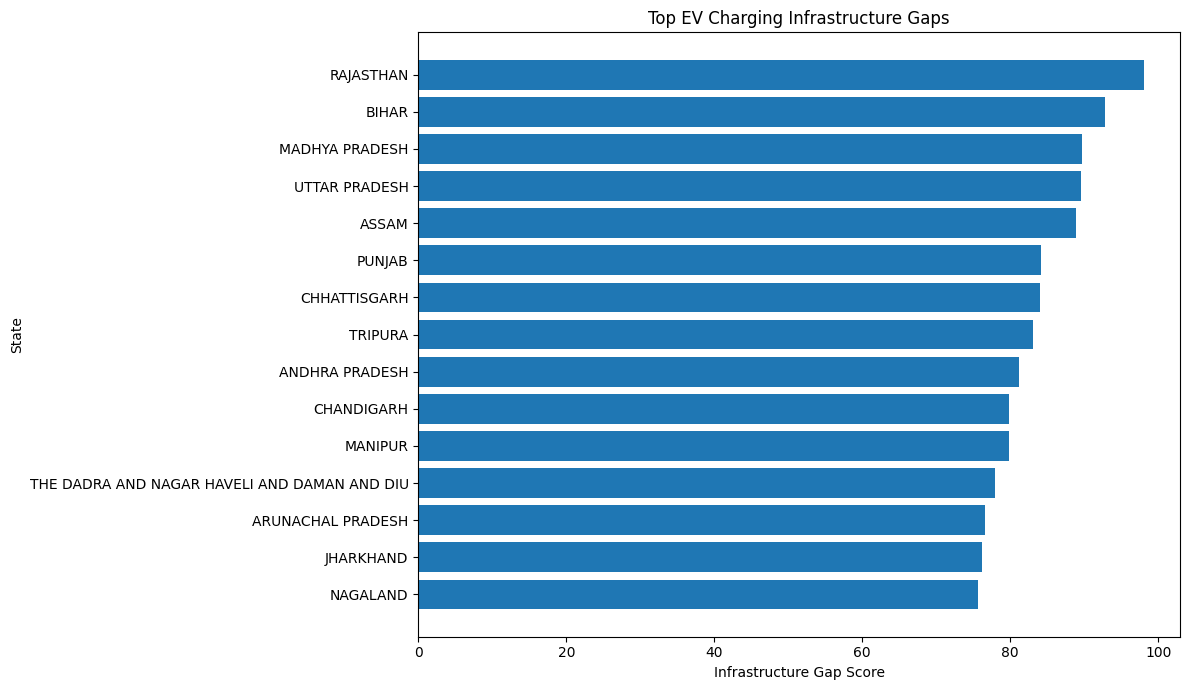

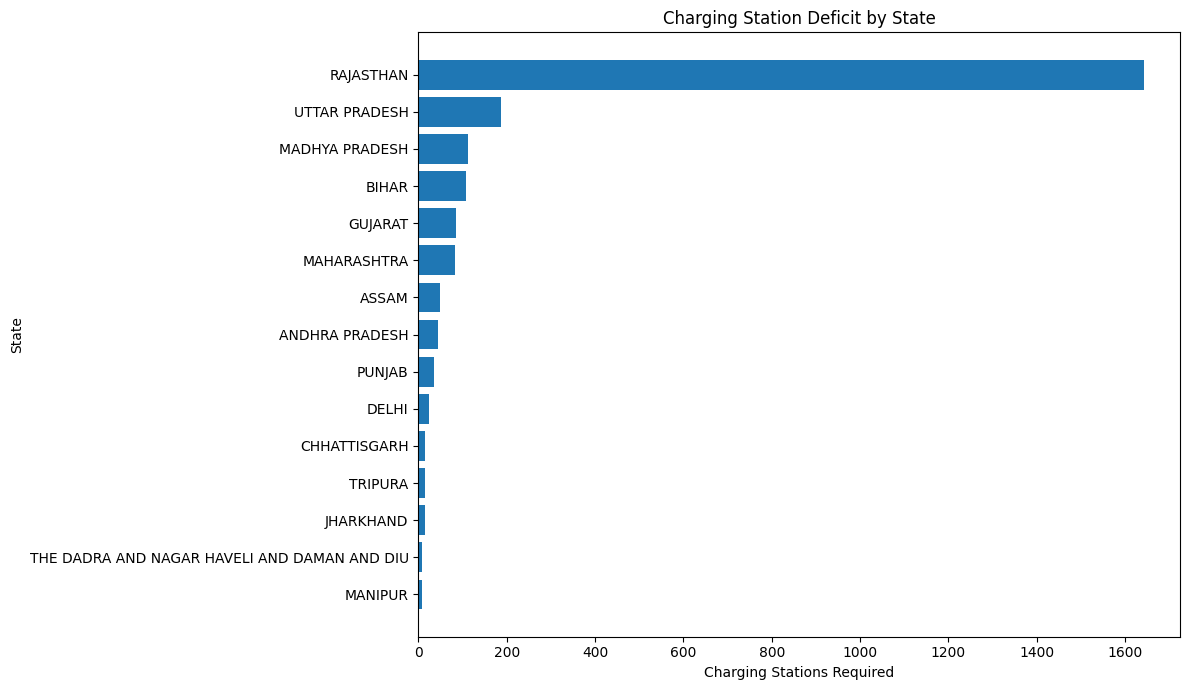


PIPELINE COMPLETED

Generated files:

outputs/
│
├── infrastructure_gap_dataset.csv
├── infrastructure_gap_score.png
└── charging_station_deficit.png



In [3]:
# ============================================================
# INFRASTRUCTURE GAP ANALYSIS
#
# INPUT:
#   future_ev_demand_forecast.csv
#   charging_stations.csv
#
# OUTPUT:
#   infrastructure_gap_dataset.csv
#
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURATION
# ============================================================

FORECAST_FILE = (
    "outputs/future_ev_demand_forecast.csv"
)

CHARGING_FILE = (
    "/content/charging_stations.csv"
)

OUTPUT_DIR = "outputs"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 1. LOAD FILES
# ============================================================

print("=" * 70)
print("LOADING FORECAST DATA")
print("=" * 70)

forecast = pd.read_csv(
    FORECAST_FILE
)

print(
    "Forecast shape:",
    forecast.shape
)

print(
    "\nForecast columns:"
)

print(
    forecast.columns.tolist()
)


print("\n" + "=" * 70)
print("LOADING CHARGING STATION DATA")
print("=" * 70)

stations = pd.read_csv(
    CHARGING_FILE
)

print(
    "Charging station shape:",
    stations.shape
)

print(
    "\nCharging columns:"
)

print(
    stations.columns.tolist()
)


# ============================================================
# 2. CLEAN COLUMN NAMES
# ============================================================

def clean_columns(df):

    df.columns = [

        re.sub(
            r"[^a-z0-9]+",
            "_",
            str(column)
            .strip()
            .lower()
        ).strip("_")

        for column in df.columns

    ]

    return df


forecast = clean_columns(
    forecast
)

stations = clean_columns(
    stations
)


print("\nCleaned forecast columns:")
print(
    forecast.columns.tolist()
)

print("\nCleaned station columns:")
print(
    stations.columns.tolist()
)


# ============================================================
# 3. CLEAN FORECAST DATA
# ============================================================

# Date

forecast["month"] = pd.to_datetime(
    forecast["month"],
    errors="coerce"
)


# State

forecast["state_name"] = (
    forecast["state_name"]
    .astype(str)
    .str.strip()
    .str.upper()
)


# Forecast EV

forecast["forecast_ev"] = pd.to_numeric(
    forecast["forecast_ev"],
    errors="coerce"
)


forecast = forecast.dropna(
    subset=[
        "month",
        "state_name",
        "forecast_ev"
    ]
)


# ============================================================
# 4. SELECT FUTURE PERIOD
# ============================================================

# We use the latest forecast month for
# infrastructure planning.

latest_forecast_month = (
    forecast["month"].max()
)


latest_forecast = forecast[
    forecast["month"]
    ==
    latest_forecast_month
].copy()


print("\n" + "=" * 70)
print("LATEST FORECAST")
print("=" * 70)

print(
    "Forecast month:",
    latest_forecast_month
)

print(
    "States:",
    len(latest_forecast)
)


# ============================================================
# 5. CLEAN CHARGING STATIONS
# ============================================================

# ------------------------------------------------------------
# STATE
# ------------------------------------------------------------

if "state" not in stations.columns:

    raise ValueError(
        "The charging_stations.csv file must contain "
        "a 'state' column."
    )


stations["state"] = (
    stations["state"]
    .astype(str)
    .str.strip()
    .str.upper()
)


# ------------------------------------------------------------
# LATITUDE / LONGITUDE
# ------------------------------------------------------------

if "latitude" in stations.columns:

    stations["latitude"] = pd.to_numeric(
        stations["latitude"],
        errors="coerce"
    )

if "longitude" in stations.columns:

    stations["longitude"] = pd.to_numeric(
        stations["longitude"],
        errors="coerce"
    )


# ------------------------------------------------------------
# CONNECTIONS
# ------------------------------------------------------------

if "total_connections" in stations.columns:

    stations["total_connections"] = pd.to_numeric(
        stations["total_connections"],
        errors="coerce"
    ).fillna(0)

else:

    stations["total_connections"] = 0


# ------------------------------------------------------------
# FAST CHARGER
# ------------------------------------------------------------

if "is_fast_charger" in stations.columns:

    stations["is_fast_charger"] = pd.to_numeric(
        stations["is_fast_charger"],
        errors="coerce"
    ).fillna(0)

else:

    # Calculate from power if available

    if "max_power_kw" in stations.columns:

        stations["max_power_kw"] = pd.to_numeric(
            stations["max_power_kw"],
            errors="coerce"
        )

        stations["is_fast_charger"] = (
            stations["max_power_kw"] >= 50
        ).astype(int)

    else:

        stations["is_fast_charger"] = 0


# ============================================================
# 6. OPERATIONAL STATIONS
# ============================================================

if "is_operational" in stations.columns:

    stations["is_operational"] = pd.to_numeric(
        stations["is_operational"],
        errors="coerce"
    ).fillna(0)

else:

    stations["is_operational"] = 1


# ============================================================
# 7. PUBLIC STATIONS
# ============================================================

if "is_public" in stations.columns:

    stations["is_public"] = pd.to_numeric(
        stations["is_public"],
        errors="coerce"
    ).fillna(0)

else:

    stations["is_public"] = 1


# ============================================================
# 8. COUNT STATIONS BY STATE
# ============================================================

station_state = (
    stations
    .groupby("state")
    .agg(

        existing_stations=(
            "station_id",
            "nunique"
        )
        if "station_id" in stations.columns
        else (
            "state",
            "size"
        ),

        total_connections=(
            "total_connections",
            "sum"
        ),

        fast_chargers=(
            "is_fast_charger",
            "sum"
        ),

        operational_stations=(
            "is_operational",
            "sum"
        ),

        public_stations=(
            "is_public",
            "sum"
        )

    )
    .reset_index()
)


# ============================================================
# 9. MERGE FORECAST + STATIONS
# ============================================================

print("\n" + "=" * 70)
print("MERGING FORECAST WITH CHARGING INFRASTRUCTURE")
print("=" * 70)


gap = latest_forecast.merge(
    station_state,
    left_on="state_name",
    right_on="state",
    how="left"
)


# ============================================================
# 10. FILL MISSING STATION DATA
# ============================================================

station_columns = [
    "existing_stations",
    "total_connections",
    "fast_chargers",
    "operational_stations",
    "public_stations"
]


for column in station_columns:

    if column in gap.columns:

        gap[column] = gap[column].fillna(0)


# ============================================================
# 11. REMOVE EXTRA STATE COLUMN
# ============================================================

if "state" in gap.columns:

    gap = gap.drop(
        columns=["state"]
    )


# ============================================================
# 12. EV PER STATION
# ============================================================

gap["ev_per_station"] = np.where(

    gap["existing_stations"] > 0,

    gap["forecast_ev"]
    /
    gap["existing_stations"],

    gap["forecast_ev"]

)


# ============================================================
# 13. EV PER FAST CHARGER
# ============================================================

gap["ev_per_fast_charger"] = np.where(

    gap["fast_chargers"] > 0,

    gap["forecast_ev"]
    /
    gap["fast_chargers"],

    gap["forecast_ev"]

)


# ============================================================
# 14. ESTIMATE REQUIRED STATIONS
# ============================================================

# ------------------------------------------------------------
# Planning assumption
#
# One charging station is assumed to support
# approximately 100 EVs.
#
# This is a MODELING ASSUMPTION, not an official standard.
#
# You can change this value later.
# ------------------------------------------------------------

EV_PER_STATION_TARGET = 100


gap["required_stations"] = np.ceil(

    gap["forecast_ev"]
    /
    EV_PER_STATION_TARGET

)


# ============================================================
# 15. STATION DEFICIT
# ============================================================

gap["station_deficit"] = (

    gap["required_stations"]
    -
    gap["existing_stations"]

)


gap["station_deficit"] = (
    gap["station_deficit"]
    .clip(lower=0)
)


# ============================================================
# 16. INFRASTRUCTURE COVERAGE
# ============================================================

gap["infrastructure_coverage"] = np.where(

    gap["required_stations"] > 0,

    gap["existing_stations"]
    /
    gap["required_stations"]
    *
    100,

    0

)


# ============================================================
# 17. INFRASTRUCTURE GAP %
# ============================================================

gap["infrastructure_gap_percent"] = (

    100
    -
    gap["infrastructure_coverage"]

)


gap["infrastructure_gap_percent"] = (
    gap["infrastructure_gap_percent"]
    .clip(
        lower=0,
        upper=100
    )
)


# ============================================================
# 18. DEMAND SCORE
# ============================================================

# Rank forecast demand from 0 to 100

if len(gap) > 1:

    gap["demand_score"] = (
        gap["forecast_ev"]
        .rank(
            pct=True
        )
        * 100
    )

else:

    gap["demand_score"] = 100


# ============================================================
# 19. GAP SCORE
# ============================================================

gap["gap_score"] = (
    gap["infrastructure_gap_percent"]
    * 0.70
    +
    gap["demand_score"]
    * 0.30
)


# ============================================================
# 20. PRIORITY
# ============================================================

def assign_priority(score):

    if score >= 75:

        return "HIGH"

    elif score >= 50:

        return "MEDIUM"

    else:

        return "LOW"


gap["priority"] = (
    gap["gap_score"]
    .apply(assign_priority)
)


# ============================================================
# 21. RECOMMENDED NEW STATIONS
# ============================================================

gap["recommended_new_stations"] = (
    gap["station_deficit"]
    .round()
    .astype(int)
)


# ============================================================
# 22. SORT BY PRIORITY
# ============================================================

priority_order = {
    "HIGH": 1,
    "MEDIUM": 2,
    "LOW": 3
}


gap["priority_rank"] = (
    gap["priority"]
    .map(priority_order)
)


gap = gap.sort_values(
    [
        "priority_rank",
        "gap_score"
    ],
    ascending=[
        True,
        False
    ]
)


# ============================================================
# 23. SAVE DATASET
# ============================================================

OUTPUT_FILE = (
    f"{OUTPUT_DIR}/"
    "infrastructure_gap_dataset.csv"
)


gap.to_csv(
    OUTPUT_FILE,
    index=False
)


print("\n" + "=" * 70)
print("INFRASTRUCTURE GAP DATASET CREATED")
print("=" * 70)

print(
    "File:",
    OUTPUT_FILE
)

print(
    "Rows:",
    len(gap)
)


# ============================================================
# 24. DISPLAY RESULTS
# ============================================================

display_columns = [

    "state_name",

    "forecast_ev",

    "existing_stations",

    "fast_chargers",

    "total_connections",

    "ev_per_station",

    "required_stations",

    "station_deficit",

    "infrastructure_gap_percent",

    "gap_score",

    "priority",

    "recommended_new_stations"

]


display_columns = [
    col
    for col in display_columns
    if col in gap.columns
]


print("\n" + "=" * 70)
print("TOP PRIORITY LOCATIONS")
print("=" * 70)

print(
    gap[
        display_columns
    ].head(20).to_string(
        index=False
    )
)


# ============================================================
# 25. PRIORITY COUNTS
# ============================================================

print("\n" + "=" * 70)
print("PRIORITY SUMMARY")
print("=" * 70)

print(
    gap["priority"]
    .value_counts()
)


# ============================================================
# 26. TOTAL STATIONS REQUIRED
# ============================================================

print("\n" + "=" * 70)
print("INFRASTRUCTURE SUMMARY")
print("=" * 70)

print(
    "Forecast EV demand:",
    f"{gap['forecast_ev'].sum():,.0f}"
)

print(
    "Existing stations:",
    f"{gap['existing_stations'].sum():,.0f}"
)

print(
    "Required stations:",
    f"{gap['required_stations'].sum():,.0f}"
)

print(
    "Station deficit:",
    f"{gap['station_deficit'].sum():,.0f}"
)

print(
    "Recommended new stations:",
    f"{gap['recommended_new_stations'].sum():,.0f}"
)


# ============================================================
# 27. VISUALIZATION
# ============================================================

top = gap.head(15).copy()

plt.figure(
    figsize=(12, 7)
)

plt.barh(
    top["state_name"][::-1],
    top["gap_score"][::-1]
)

plt.xlabel(
    "Infrastructure Gap Score"
)

plt.ylabel(
    "State"
)

plt.title(
    "Top EV Charging Infrastructure Gaps"
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/"
    "infrastructure_gap_score.png",
    dpi=300
)

plt.show()


# ============================================================
# 28. DEFICIT VISUALIZATION
# ============================================================

top_deficit = (
    gap
    .sort_values(
        "station_deficit",
        ascending=False
    )
    .head(15)
)


plt.figure(
    figsize=(12, 7)
)

plt.barh(
    top_deficit["state_name"][::-1],
    top_deficit["station_deficit"][::-1]
)

plt.xlabel(
    "Charging Stations Required"
)

plt.ylabel(
    "State"
)

plt.title(
    "Charging Station Deficit by State"
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/"
    "charging_station_deficit.png",
    dpi=300
)

plt.show()


# ============================================================
# 29. FINAL
# ============================================================

print("\n" + "=" * 70)
print("PIPELINE COMPLETED")
print("=" * 70)

print("""
Generated files:

outputs/
│
├── infrastructure_gap_dataset.csv
├── infrastructure_gap_score.png
└── charging_station_deficit.png
""")